<a href="https://colab.research.google.com/github/luisrodriguezh-crypto/PCA-y-sistema-de-recomendaci-n/blob/main/sistemas_de_recomendacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="font-family: 'Georgia', serif; line-height:1.6; color:#222; max-width:900px; margin:auto; text-align:justify;">

<h1 style="text-align:center; color:#1F3A5F; margin-bottom:5px;">Sistemas de Recomendación</h1>
<h3 style="text-align:center; color:#555; margin-top:0;">¿Cómo sabe Netflix qué película podría gustarte?</h3>

<div style="background:#f8f9fa; padding:12px 18px; border-left:4px solid #1F3A5F; margin:20px 0;">
A veces parece que las plataformas saben lo que queremos antes incluso de que nosotros lo sepamos.
</div>

<p>
Basta con ver una película, buscar cierto tipo de contenido o incluso mostrar interés por un género específico para que, poco tiempo después, aparezcan recomendaciones sorprendentemente acertadas. En ocasiones la precisión es tan buena que parece que el sistema entendiera exactamente lo que queremos ver. Y ahí aparece esa sensación incómoda pero familiar: <strong>"esto me conoce demasiado bien"</strong>.
</p>

<p>
Es fácil imaginar que detrás de cada recomendación existe algún tipo de vigilancia detallada, como si hubiera una persona observando nuestros hábitos y tomando nota de cada preferencia. La idea de alguien registrando qué vemos, cuándo lo vemos y qué nos gusta puede sonar inquietante. Sin embargo, la realidad es mucho menos dramática... y mucho más interesante.
</p>

<p>
No existe una persona detrás de la plataforma decidiendo manualmente qué recomendarle a cada usuario. Además de ser una tarea aterradora, sería completamente imposible. Pensemos en la cantidad de usuarios que tiene una plataforma de streaming y en la enorme cantidad de películas disponibles: tratar de decidir manualmente qué recomendarle a cada persona sería una tarea infinita.
</p>

<p>
La verdadera pregunta entonces no es si alguien nos observa, sino <strong>cómo puede un sistema predecir algo tan personal como nuestros gustos</strong>. Y aquí es donde un problema cotidiano se convierte en un problema matemático fascinante.
</p>

<h3 style="color:#1F3A5F; margin-top:30px;">La dimensión real del problema</h3>

<p>
Para entender la magnitud del reto, conviene plantear una pregunta sencilla: <strong>¿qué porcentaje del catálogo total de una plataforma representa el contenido que un usuario ha visto?</strong> La respuesta, en la mayoría de los casos, es mínima. En plataformas como Netflix existen miles de películas y series, mientras que cada usuario solo interactúa con una fracción muy pequeña del catálogo.
</p>

<p>
Eso significa que la información disponible sobre cada usuario es extremadamente limitada. Además, las decisiones humanas dependen de factores que cambian constantemente: el estado de ánimo, el tiempo libre, el género que se desea ver o incluso si simplemente se quiere ver "algo fácil". Muchos de estos factores influyen en nuestras decisiones, pero no aparecen registrados directamente en los datos.
</p>

<p>
En ciencia de datos, estos factores se conocen como <strong>variables latentes</strong>, porque afectan el comportamiento del usuario aunque no sean observables explícitamente. La plataforma puede saber que vimos una película, pero no sabe exactamente por qué la vimos. Y eso vuelve el problema mucho más complejo: no solo faltan datos, también faltan las razones detrás de esos datos.
</p>

<h3 style="color:#1F3A5F; margin-top:30px;">Representación matemática</h3>

<p>
Para modelar esta situación se construye una matriz \(R\), donde cada fila representa a un usuario, cada columna representa una película y cada entrada \(r_{ij}\) corresponde a la calificación que el usuario \(i\) asigna a la película \(j\).
</p>

<div style="text-align:center; margin:20px 0;">
$$
R=
\begin{bmatrix}
5 & \cdot & 4 & \cdot \\
\cdot & 3 & \cdot & 2 \\
4 & \cdot & 5 & \cdot
\end{bmatrix}
$$
</div>

<p>
Los puntos representan valores faltantes, es decir, películas que el usuario no ha calificado. Como ningún usuario ha visto todas las películas disponibles, la mayor parte de esta matriz está vacía. Entonces aparece el problema fundamental de los sistemas de recomendación: <strong>¿cómo predecir las entradas faltantes?</strong>
</p>

<p>
Aunque la matriz contiene muchos espacios vacíos, las calificaciones observadas aún presentan patrones útiles. Usuarios con gustos similares tienden a calificar de manera parecida, y películas similares tienden a atraer perfiles semejantes. Esto significa que, aunque los datos estén incompletos, existe una estructura subyacente que puede aprovecharse para estimar preferencias futuras.
</p>

<h3 style="color:#1F3A5F; margin-top:30px;">Completación de matrices y SoftImpute</h3>

<p>
Una forma elegante de resolver este problema es mediante técnicas de <strong>completación de matrices</strong>, cuyo objetivo es reconstruir los valores faltantes utilizando la estructura de los datos observados. En este proyecto se utiliza el algoritmo <strong>SoftImpute</strong>, que aproxima la matriz original mediante una factorización de bajo rango:
</p>

<div style="text-align:center; margin:20px 0;">
$$R \approx UV^T$$
</div>

<p>
Aquí, \(U\) representa factores latentes asociados a los usuarios y \(V\) representa factores latentes asociados a las películas. Estos factores resumen patrones ocultos, como afinidades por géneros o preferencias implícitas. Con esta representación, una calificación faltante se estima como:
</p>

<div style="text-align:center; margin:20px 0;">
$$\hat{r}_{ij} = u_i^T v_j$$
</div>

<p>
El algoritmo SoftImpute encuentra esta aproximación minimizando el error entre las calificaciones observadas y las estimadas, con una penalización que evita que el modelo se vuelva innecesariamente complejo:
</p>

<div style="text-align:center; margin:20px 0;">
$$\min_M \frac{1}{2}\sum_{(i,j)\in\Omega}(r_{ij}-m_{ij})^2+\lambda \|M\|_*$$
</div>

<p>
Los sistemas de recomendación no funcionan porque alguien observe manualmente nuestras decisiones. Funcionan porque incluso en matrices incompletas existen patrones ocultos suficientemente fuertes como para anticipar preferencias futuras.
</p>

<div style="background:#f8f9fa; padding:12px 18px; border-left:4px solid #1F3A5F; margin:20px 0;">
No hay alguien espiando tus gustos; hay matemáticas encontrando patrones donde nosotros solo vemos recomendaciones. Hoy tal vez usamos estos modelos para predecir qué película podría gustarnos; mañana quizá los usemos para predecir qué mundos podrían albergar vida. Al final, no se trata de que alguien nos observe, sino de aprender a encontrar patrones en aquello que todavía no conocemos.
</div>

</div>

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings

from sklearn.metrics import mean_squared_error
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
np.random.seed(42)


## 0. El problema: una matriz incompleta

Una vez entendido el problema, el siguiente paso es traducirlo a código. Antes de cargar cualquier dato, necesitamos la herramienta matemática central de este proyecto: **SoftImpute**.

El algoritmo funciona de forma iterativa. En cada paso, calcula la descomposición en valores singulares (SVD) de la matriz actual, aplica un umbral suave a esos valores singulares —lo que promueve soluciones de bajo rango— y luego actualiza únicamente las posiciones donde faltaban datos. Los valores que sí existían permanecen intactos. Este ciclo se repite hasta que la matriz deja de cambiar significativamente entre una iteración y la siguiente.

El parámetro $\lambda$ (`shrinkage`) controla qué tan agresivo es ese umbral: valores altos simplifican más el modelo, valores bajos permiten capturar más detalle.

In [33]:
def soft_impute(X_missing, max_rank=20, shrinkage=0.5, max_iter=100, tol=1e-3, verbose=False):
    """
    SoftImpute: completacion de matrices via factorizacion de bajo rango iterativa.

    Parametros
    ----------
    X_missing : ndarray con NaN en posiciones faltantes
    max_rank  : numero maximo de factores latentes a conservar
    shrinkage : lambda, umbral de regularizacion sobre valores singulares
    max_iter  : iteraciones maximas
    tol       : criterio de convergencia (cambio relativo en la matriz)

    Retorna
    -------
    X_completed : ndarray con todos los valores imputados
    """
    X = X_missing.astype(float).copy()
    mask_obs = ~np.isnan(X_missing)          # True donde hay datos reales

    # Paso 0: inicializar NaN con media de cada columna
    col_means = np.nanmean(X, axis=0)
    for j in range(X.shape[1]):
        X[np.isnan(X[:, j]), j] = col_means[j]

    for it in range(max_iter):
        X_prev = X.copy()

        # Paso 1: SVD
        U, s, Vt = np.linalg.svd(X, full_matrices=False)

        # Paso 2: umbral suave sobre valores singulares
        s_thresh = np.maximum(s - shrinkage, 0)
        r = min(max_rank, int(np.sum(s_thresh > 0)))

        # Paso 3: reconstruccion de bajo rango
        X_approx = (U[:, :r] * s_thresh[:r]) @ Vt[:r, :]

        # Paso 4: actualizar SOLO posiciones faltantes
        X[~mask_obs] = X_approx[~mask_obs]

        # Convergencia
        delta = np.linalg.norm(X - X_prev) / (np.linalg.norm(X_prev) + 1e-10)
        if verbose:
            print(f'  iter {it+1:3d} | rango efectivo={r} | delta={delta:.2e}')
        if delta < tol:
            if verbose:
                print(f'  Convergencia en iteracion {it+1}.')
            break

    return X

print('soft_impute() definida.')

soft_impute() definida.


---
## 1. Dataset: MovieLens 100k

Para probar el sistema de recomendación necesitamos datos reales de preferencias. **MovieLens 100k** es el benchmark clásico para este tipo de problemas: contiene exactamente 100,000 calificaciones de 943 usuarios sobre 1,682 películas, en una escala del 1 al 5.

Trabajaremos con dos archivos:
- `u.data` — cada línea es una calificación: quién la dio, a qué película, qué puntaje y cuándo.
- `u.item` — información de cada película: título y 19 columnas binarias de género.

In [34]:
# Cargar ratings
ratings = pd.read_csv(
    '/content/u.data',
    sep='\t',
    names=['userId', 'movieId', 'rating', 'timestamp']
)

# Cargar informacion de peliculas
genre_cols = [
    'unknown', 'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy', 'Crime',
    'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
    'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]
movies = pd.read_csv(
    '/content/u.item',
    sep='|', encoding='latin-1',
    names=['movieId', 'title', 'release_date', 'video_release', 'IMDb_URL'] + genre_cols
)[['movieId', 'title'] + genre_cols]

print('=== u.data (ratings) ===')
print(f'Shape: {ratings.shape}')
display(ratings.head())

print('\n=== u.item (peliculas) ===')
print(f'Shape: {movies.shape}')
display(movies[['movieId', 'title']].head())

=== u.data (ratings) ===
Shape: (100000, 4)


,userId,movieId,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596



=== u.item (peliculas) ===
Shape: (1682, 21)


,movieId,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


<div style="background:#f8f9fa; padding:12px 18px; border-left:4px solid #1F3A5F; margin:20px 0; font-family:Georgia, serif;">
La estructura es simple: cada rating es una tupla (usuario, película, calificación). Lo que hace interesante este dataset no es su complejidad sino su <em>escasez</em> — el hecho de que la mayoría de las combinaciones posibles simplemente no existen.
</div>

=== Caracteristicas del dataset ===
Tamano total       : (100000, 4)
Usuarios unicos    : 943
Peliculas unicas   : 1682
Ratings totales    : 100,000
Tipo de datos      : {'userId': dtype('int64'), 'movieId': dtype('int64'), 'rating': dtype('int64'), 'timestamp': dtype('int64')}
Valores nulos      : 0
Rango de ratings   : 1 - 5

Densidad de la matriz: 6.3047%
  -> El 93.70% de la matriz usuario-item esta vacia (huecos)


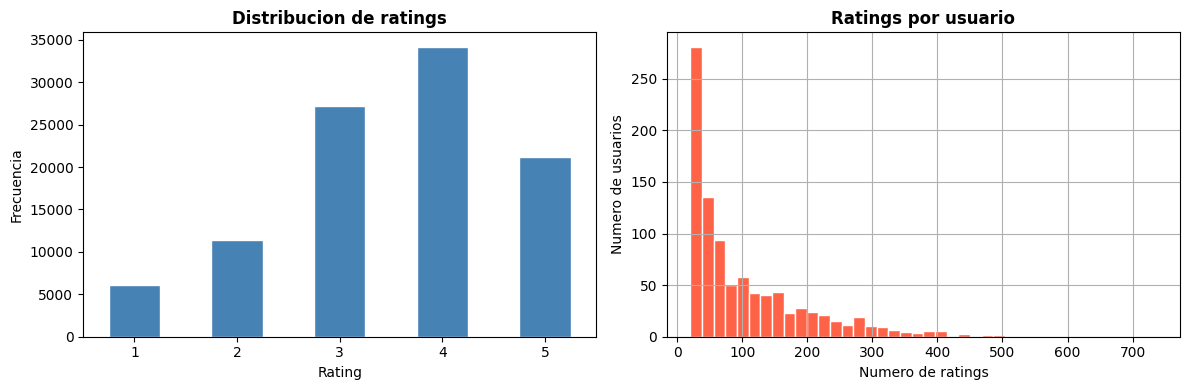


Interpretacion: la mayoria de usuarios califica entre 20 y 200 peliculas.
Con ~1,682 peliculas en el catalogo, eso representa menos del 12% del total.


In [35]:
# Caracteristicas generales
n_users   = ratings['userId'].nunique()
n_movies  = ratings['movieId'].nunique()
n_ratings = len(ratings)
density   = n_ratings / (n_users * n_movies)

print('=== Caracteristicas del dataset ===')
print(f'Tamano total       : {ratings.shape}')
print(f'Usuarios unicos    : {n_users}')
print(f'Peliculas unicas   : {n_movies}')
print(f'Ratings totales    : {n_ratings:,}')
print(f'Tipo de datos      : {ratings.dtypes.to_dict()}')
print(f'Valores nulos      : {ratings.isnull().sum().sum()}')
print(f'Rango de ratings   : {ratings["rating"].min()} - {ratings["rating"].max()}')
print(f'\nDensidad de la matriz: {density:.4%}')
print(f'  -> El {(1-density)*100:.2f}% de la matriz usuario-item esta vacia (huecos)')

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribucion de ratings', fontweight='bold')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

ratings.groupby('userId').size().hist(bins=40, ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Ratings por usuario', fontweight='bold')
axes[1].set_xlabel('Numero de ratings'); axes[1].set_ylabel('Numero de usuarios')

plt.tight_layout()
plt.show()

print('\nInterpretacion: la mayoria de usuarios califica entre 20 y 200 peliculas.')
print('Con ~1,682 peliculas en el catalogo, eso representa menos del 12% del total.')

<div style="background:#f8f9fa; padding:12px 18px; border-left:4px solid #1F3A5F; margin:20px 0; font-family:Georgia, serif;">
<strong>¿Qué nos dice esto?</strong> Con 943 usuarios y 1,682 películas, la matriz completa tendría más de 1.5 millones de entradas. Pero solo existen 100,000 calificaciones reales: el <strong>6.3% del total</strong>. El 93.7% restante es información que no tenemos y que el sistema deberá inferir.

La distribución de la izquierda muestra que los usuarios tienden a dar calificaciones intermedias (3-4), no extremos. La de la derecha revela algo importante: la actividad es muy desigual. Algunos usuarios calificaron cientos de películas; la mayoría apenas unas decenas. Esto es lo que hace que el problema sea difícil: tenemos muy poca información de cada persona.
</div>

---
## 2. Matriz usuario-item

Antes de aplicar cualquier algoritmo, necesitamos transformar los datos de su formato original (una lista de tuplas) a la estructura que SoftImpute espera: una **matriz**.

En esta matriz, cada fila es un usuario, cada columna es una película, y el valor en la posición $(i, j)$ es la calificación que el usuario $i$ le dio a la película $j$. Donde no hay calificación, hay un `NaN`.

In [36]:
# Construir la matriz usuario-item
R = ratings.pivot(index='userId', columns='movieId', values='rating')

print(f'Dimensiones de R: {R.shape}  (usuarios x peliculas)')
print(f'Valores presentes (ratings conocidos) : {R.notna().sum().sum():,}')
print(f'Valores faltantes (NaN)               : {R.isna().sum().sum():,}')
print(f'Densidad                              : {R.notna().mean().mean():.4%}')
print()
display(R.iloc[:5, :8])   # vista parcial

Dimensiones de R: (943, 1682)  (usuarios x peliculas)
Valores presentes (ratings conocidos) : 100,000
Valores faltantes (NaN)               : 1,486,126
Densidad                              : 6.3047%



movieId,1,2,3,4,5,6,7,8
userId,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN


<div style="background:#f8f9fa; padding:12px 18px; border-left:4px solid #1F3A5F; margin:20px 0; font-family:Georgia, serif;">
<strong>¿Qué vemos aquí?</strong> El usuario 1 es inusualmente activo y calificó las primeras 8 películas. El usuario 2 solo calificó la primera. Los usuarios 3 y 4 no calificaron ninguna de estas ocho. Esta es la realidad de la matriz: filas densas junto a filas casi vacías, sin ningún patrón obvio.
</div>

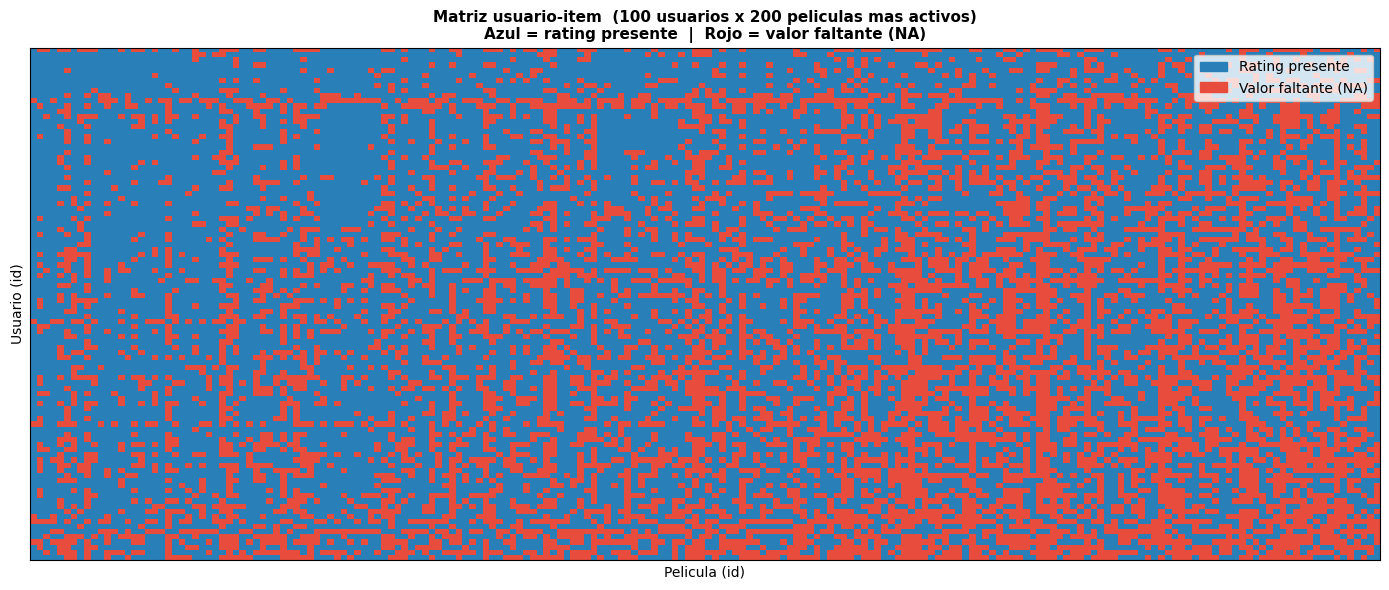

Densidad en este subconjunto: 62.82%
Incluso entre los usuarios y peliculas MAS activos, la matriz sigue siendo muy dispersa.


In [37]:
# Heatmap de NaN — subconjunto representativo
# Tomamos los 100 usuarios y 200 peliculas con mas interacciones
top_users  = R.notna().sum(axis=1).nlargest(100).index
top_movies = R.notna().sum(axis=0).nlargest(200).index
R_sub = R.loc[top_users, top_movies]

fig, ax = plt.subplots(figsize=(14, 6))
present = R_sub.notna().astype(float)   # 1 = rating presente, 0 = NA

cmap_na = mcolors.ListedColormap(['#e74c3c', '#2980b9'])   # rojo=NA, azul=presente
ax.imshow(present.values, aspect='auto', cmap=cmap_na, vmin=0, vmax=1,
          interpolation='nearest')

ax.set_title(
    'Matriz usuario-item  (100 usuarios x 200 peliculas mas activos)\n'
    'Azul = rating presente  |  Rojo = valor faltante (NA)',
    fontsize=11, fontweight='bold')
ax.set_xlabel('Pelicula (id)', fontsize=10)
ax.set_ylabel('Usuario (id)', fontsize=10)
ax.set_xticks([]); ax.set_yticks([])

legend_elems = [Patch(color='#2980b9', label='Rating presente'),
                Patch(color='#e74c3c', label='Valor faltante (NA)')]
ax.legend(handles=legend_elems, loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

print(f'Densidad en este subconjunto: {present.mean().mean():.2%}')
print('Incluso entre los usuarios y peliculas MAS activos, la matriz sigue siendo muy dispersa.')

<div style="background:#f8f9fa; padding:12px 18px; border-left:4px solid #1F3A5F; margin:20px 0; font-family:Georgia, serif;">
<strong>Esto es exactamente el problema.</strong> Incluso tomando únicamente los 100 usuarios y las 200 películas <em>más activas</em> del dataset — es decir, el subconjunto más denso posible — la matriz sigue siendo mayormente roja. Fuera de este subconjunto, la dispersión es aún mayor. SoftImpute tendrá que inferir preferencias a partir de esta información fragmentada.
</div>

---
## 3. Preprocesamiento

Antes de aplicar SoftImpute necesitamos preparar la matriz con dos pasos fundamentales.

**Paso 1 — Esconder el 10% de los ratings.** Para evaluar qué tan bien funciona el sistema, necesitamos ejemplos de los que ya conocemos la respuesta correcta. Tomamos el 10% de los ratings existentes, los ocultamos de la matriz de entrenamiento y los guardamos aparte. Al final del proceso, compararemos las predicciones del modelo contra estos valores reales.

**Paso 2 — Centrar ratings por usuario.** Este paso corrige un sesgo que de otro modo distorsionaría los resultados. Imaginemos dos usuarios: uno que siempre da 4 o 5 estrellas a todo, y otro que es más estricto y rara vez supera el 3. Ambos podrían estar completamente de acuerdo en qué películas son buenas y cuáles no, pero sus escalas personales son distintas. Al restarle a cada usuario su propia media, ambos quedan en la misma escala relativa y el algoritmo puede comparar preferencias de forma justa.

In [38]:
R_np = R.values.copy().astype(float)   # (943, 1682)

# --- Paso 1: esconder el 10% de los ratings ---
rng = np.random.default_rng(42)
observed_idx   = np.argwhere(~np.isnan(R_np))             # posiciones con rating
n_hide         = int(0.10 * len(observed_idx))
hide_sel       = rng.choice(len(observed_idx), size=n_hide, replace=False)
hidden_positions = observed_idx[hide_sel]                  # posiciones escondidas

R_train = R_np.copy()
for r, c in hidden_positions:
    R_train[r, c] = np.nan

hidden_true = np.array([R_np[r, c] for r, c in hidden_positions])  # valores reales

print(f'Ratings observados totales   : {(~np.isnan(R_np)).sum():,}')
print(f'Ratings escondidos (10%)     : {n_hide:,}')
print(f'Ratings disponibles en train : {(~np.isnan(R_train)).sum():,}')

Ratings observados totales   : 100,000
Ratings escondidos (10%)     : 10,000
Ratings disponibles en train : 90,000


<div style="background:#f8f9fa; padding:12px 18px; border-left:4px solid #1F3A5F; margin:20px 0; font-family:Georgia, serif;">
De los 100,000 ratings disponibles, 10,000 se reservan como conjunto de evaluación. El modelo los verá como huecos y tendrá que predecirlos. Luego compararemos esas predicciones contra los valores reales que ocultamos.
</div>

In [39]:
# --- Paso 2: centrar ratings por usuario ---
user_means = np.nanmean(R_train, axis=1, keepdims=True)    # (943, 1) media de cada usuario
R_centered = R_train - user_means                          # centrar

print('Media por usuario antes de centrar (primeros 8):')
for i in range(8):
    n_rated = int((~np.isnan(R_train[i])).sum())
    print(f'  Usuario {R.index[i]:3d}: media = {user_means[i, 0]:.2f}  ({n_rated} ratings)')

print(f'\nMedia global despues de centrar : {np.nanmean(R_centered):.4f}  (debe ser ~0)')
print('\nCada usuario ahora tiene media 0 -> el algoritmo trabaja con preferencias relativas.')

Media por usuario antes de centrar (primeros 8):
  Usuario   1: media = 3.63  (249 ratings)
  Usuario   2: media = 3.66  (56 ratings)
  Usuario   3: media = 2.82  (50 ratings)
  Usuario   4: media = 4.25  (20 ratings)
  Usuario   5: media = 2.83  (149 ratings)
  Usuario   6: media = 3.65  (191 ratings)
  Usuario   7: media = 3.97  (368 ratings)
  Usuario   8: media = 3.76  (55 ratings)

Media global despues de centrar : -0.0000  (debe ser ~0)

Cada usuario ahora tiene media 0 -> el algoritmo trabaja con preferencias relativas.


<div style="background:#f8f9fa; padding:12px 18px; border-left:4px solid #1F3A5F; margin:20px 0; font-family:Georgia, serif;">
<strong>¿Qué observamos?</strong> Las medias varían bastante entre usuarios: el usuario 4 tiene una media de 4.25 (crítico muy generoso), mientras que el usuario 3 solo llega a 2.82 (mucho más exigente). Después del centrado, todos parten de 0. Un rating de +1.5 ahora significa lo mismo para cualquier usuario: "le gustó bastante más de lo normal", sin importar si ese usuario acostumbra dar 2s o 5s.
</div>

---
## 4. Sistema de Recomendación

Con la matriz centrada y los ratings escondidos listos, es momento de aplicar SoftImpute. El objetivo es simple: dado que solo conocemos el 6% de las preferencias, inferir el 94% restante.

El algoritmo irá iterando, ajustando su estimación en cada paso, hasta que los cambios entre una iteración y la siguiente sean lo suficientemente pequeños como para considerar que convergió.

In [40]:
print('Aplicando SoftImpute...')
print(f'Dimension de la matriz: {R_centered.shape}  |  NaN: {np.isnan(R_centered).mean():.2%}')

# --- FIX para el error 'SVD did not converge' ---
# Si hay columnas en R_centered que son completamente NaN (por ejemplo, peliculas que nadie califico
# despues de esconder ratings), np.nanmean devolveria NaN para esas columnas,
# lo que causaria que el SVD falle.
# Se imputan estas columnas con 0.0 (apropiado para una matriz centrada).
R_centered_fixed = R_centered.copy()
all_nan_cols_mask = np.all(np.isnan(R_centered_fixed), axis=0)
num_all_nan_cols = np.sum(all_nan_cols_mask)

if num_all_nan_cols > 0:
    print(f'Detectadas {num_all_nan_cols} columnas completamente NaN en R_centered. Imputando con 0.0.')
    R_centered_fixed[:, all_nan_cols_mask] = 0.0
# --- FIN FIX ---

print()
R_completed_centered = soft_impute(
    R_centered_fixed, # Usar la matriz corregida
    max_rank=20,       # hasta 20 factores latentes
    shrinkage=0.5,     # lambda de regularizacion
    max_iter=50,
    tol=1e-3,
    verbose=True
)

# Descentrar: sumar de vuelta la media de cada usuario
R_completed = np.clip(R_completed_centered + user_means, 1, 5)

print(f'\nMatriz completada exitosamente.')
print(f'Rango de valores estimados: [{R_completed.min():.2f}, {R_completed.max():.2f}]')

Aplicando SoftImpute...
Dimension de la matriz: (943, 1682)  |  NaN: 94.33%
Detectadas 10 columnas completamente NaN en R_centered. Imputando con 0.0.

  iter   1 | rango efectivo=20 | delta=8.25e-02
  iter   2 | rango efectivo=20 | delta=5.67e-02
  iter   3 | rango efectivo=20 | delta=4.50e-02
  iter   4 | rango efectivo=20 | delta=3.79e-02
  iter   5 | rango efectivo=20 | delta=3.30e-02
  iter   6 | rango efectivo=20 | delta=2.93e-02
  iter   7 | rango efectivo=20 | delta=2.65e-02
  iter   8 | rango efectivo=20 | delta=2.42e-02
  iter   9 | rango efectivo=20 | delta=2.23e-02
  iter  10 | rango efectivo=20 | delta=2.07e-02
  iter  11 | rango efectivo=20 | delta=1.93e-02
  iter  12 | rango efectivo=20 | delta=1.81e-02
  iter  13 | rango efectivo=20 | delta=1.71e-02
  iter  14 | rango efectivo=20 | delta=1.61e-02
  iter  15 | rango efectivo=20 | delta=1.53e-02
  iter  16 | rango efectivo=20 | delta=1.45e-02
  iter  17 | rango efectivo=20 | delta=1.38e-02
  iter  18 | rango efectivo=20 |

<div style="background:#f8f9fa; padding:12px 18px; border-left:4px solid #1F3A5F; margin:20px 0; font-family:Georgia, serif;">
<strong>¿Qué significa que el delta disminuya?</strong> En cada iteración, el algoritmo actualiza su estimación de los valores faltantes. El delta mide cuánto cambió la matriz completa respecto a la iteración anterior. Que vaya bajando de 8.25e-02 hacia valores menores indica que el modelo está convergiendo: sus estimaciones se estabilizan. Al llegar a las 50 iteraciones sin alcanzar el umbral de convergencia, simplemente usamos la mejor estimación disponible.
</div>

=== Calidad de reconstruccion en los ratings escondidos ===
RMSE : 1.0191
MAE  : 0.7820

El RMSE indica el error promedio en escala de ratings (1-5).
Un RMSE ~1 es un resultado tipico para filtrado colaborativo clasico.


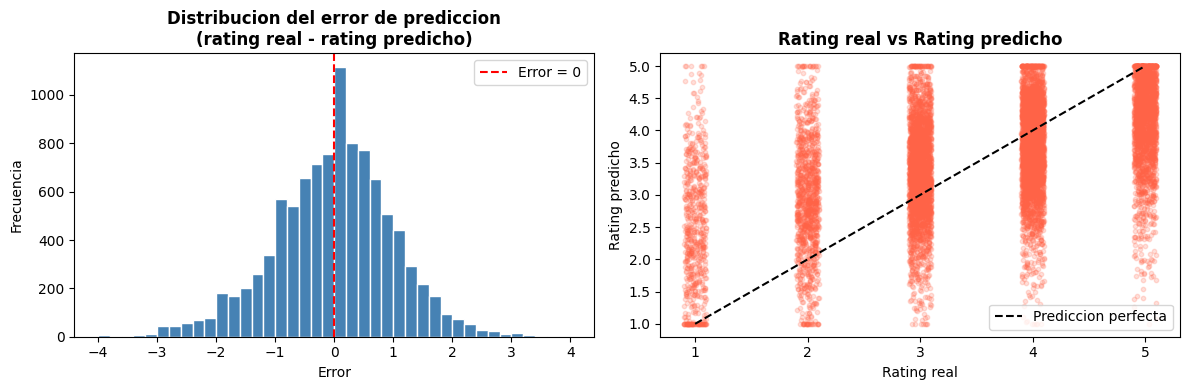

In [41]:
# Evaluacion: predicciones vs ratings escondidos (ground truth)
hidden_pred = np.array([R_completed[r, c] for r, c in hidden_positions])

rmse = np.sqrt(mean_squared_error(hidden_true, hidden_pred))
mae  = np.mean(np.abs(hidden_true - hidden_pred))

print('=== Calidad de reconstruccion en los ratings escondidos ===')
print(f'RMSE : {rmse:.4f}')
print(f'MAE  : {mae:.4f}')
print()
print('El RMSE indica el error promedio en escala de ratings (1-5).')
print('Un RMSE ~1 es un resultado tipico para filtrado colaborativo clasico.')

errors = hidden_true - hidden_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(errors, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', lw=1.5, label='Error = 0')
axes[0].set_title('Distribucion del error de prediccion\n(rating real - rating predicho)',
                  fontweight='bold')
axes[0].set_xlabel('Error'); axes[0].set_ylabel('Frecuencia')
axes[0].legend()

axes[1].scatter(hidden_true + np.random.uniform(-0.1, 0.1, len(hidden_true)),
                hidden_pred, alpha=0.2, s=10, color='tomato')
axes[1].plot([1, 5], [1, 5], 'k--', lw=1.5, label='Prediccion perfecta')
axes[1].set_xlabel('Rating real'); axes[1].set_ylabel('Rating predicho')
axes[1].set_title('Rating real vs Rating predicho', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="background:#f8f9fa; padding:12px 18px; border-left:4px solid #1F3A5F; margin:20px 0; font-family:Georgia, serif;">
<strong>¿Cómo interpretar RMSE = 1.02 y MAE = 0.78?</strong>

En una escala de 1 a 5, un error promedio de ~1 punto significa que cuando el sistema predice que a alguien le gustará una película con rating 4, la calificación real es típicamente un 3 o un 5. No es perfecto, pero es suficientemente útil para distinguir películas que le gustarían mucho al usuario de las que probablemente no le interesarían.

El histograma muestra que la distribución del error está centrada en 0 — el modelo no sobreestima ni subestima sistemáticamente, simplemente tiene incertidumbre. El gráfico de dispersión confirma que hay correlación entre lo predicho y lo real: las predicciones van en la dirección correcta.
</div>

---
## 5. Recomendaciones para un usuario

La prueba final: tomamos un usuario aleatorio y generamos sus 10 recomendaciones principales. La lógica es directa — ignoramos todo lo que ya calificó y ordenamos el resto por rating estimado de mayor a menor.

In [42]:
# Escoger usuario aleatorio
rng2 = np.random.default_rng(99)
user_idx = int(rng2.integers(0, R.shape[0]))
user_id  = R.index[user_idx]

rated_mask     = ~np.isnan(R_np[user_idx])          # peliculas ya calificadas
rated_movies   = R.columns[rated_mask].tolist()
unrated_movies = R.columns[~rated_mask].tolist()    # candidatas a recomendar

print(f'Usuario seleccionado        : {user_id}')
print(f'Peliculas ya calificadas    : {len(rated_movies)}')
print(f'Peliculas candidatas        : {len(unrated_movies)}')

Usuario seleccionado        : 904
Peliculas ya calificadas    : 47
Peliculas candidatas        : 1635


In [43]:
movie_col_idx = {mid: j for j, mid in enumerate(R.columns)}

# Ratings estimados para peliculas NO vistas, de mayor a menor
unrated_scores = sorted(
    [(mid, R_completed[user_idx, movie_col_idx[mid]]) for mid in unrated_movies],
    key=lambda x: x[1], reverse=True
)

# Top-10 con titulo y generos
top_n = 10
top_recs = pd.DataFrame(unrated_scores[:top_n], columns=['movieId', 'rating_estimado'])
top_recs = top_recs.merge(movies[['movieId', 'title'] + genre_cols], on='movieId')

def get_genres(row):
    return ', '.join([g for g in genre_cols if row[g] == 1])

top_recs['generos'] = top_recs.apply(get_genres, axis=1)
top_recs['rating_estimado'] = top_recs['rating_estimado'].round(3)

print(f'=== Top {top_n} recomendaciones para el Usuario {user_id} ===\n')
display(top_recs[['movieId', 'title', 'rating_estimado', 'generos']].reset_index(drop=True))

=== Top 10 recomendaciones para el Usuario 904 ===



,movieId,title,rating_estimado,generos
0,313,Titanic (1997),5.000,"Action, Drama, Romance"
1,485,My Fair Lady (1964),5.000,"Musical, Romance"
2,814,"Great Day in Harlem, A (1994)",5.000,Documentary
3,1467,"Saint of Fort Washington, The (1993)",5.000,Drama
4,1500,Santa with Muscles (1996),5.000,Comedy
5,1536,Aiqing wansui (1994),5.000,Drama
6,131,Breakfast at Tiffany's (1961),4.979,"Drama, Romance"
7,1463,"Boys, Les (1997)",4.977,Comedy
8,924,White Squall (1996),4.952,"Adventure, Drama"
9,1599,Someone Else's America (1995),4.949,Drama


<div style="background:#f8f9fa; padding:12px 18px; border-left:4px solid #1F3A5F; margin:20px 0; font-family:Georgia, serif;">
<strong>¿Por qué algunas películas tienen rating estimado exactamente 5.0?</strong> Recuerda que al final aplicamos un clip entre 1 y 5. Algunas películas muy bien posicionadas en el espacio latente del usuario pueden recibir estimaciones superiores a 5 antes del clip. Eso no invalida la recomendación — simplemente significa que el modelo tiene alta confianza en que le gustarán.

Para validar la coherencia de las recomendaciones, vale la pena compararlas con el perfil del usuario: las películas que él mismo calificó con 4 o 5.
</div>

In [44]:
# Perfil del usuario: sus mejores ratings reales (para validar coherencia)
rated_scores = sorted(
    [(mid, R_np[user_idx, movie_col_idx[mid]]) for mid in rated_movies],
    key=lambda x: x[1], reverse=True
)

top_rated = pd.DataFrame(rated_scores[:10], columns=['movieId', 'rating_real'])
top_rated = top_rated.merge(movies[['movieId', 'title'] + genre_cols], on='movieId')
top_rated['generos'] = top_rated.apply(get_genres, axis=1)

print(f'=== Perfil del Usuario {user_id} — peliculas mejor calificadas ===\n')
display(top_rated[['movieId', 'title', 'rating_real', 'generos']].reset_index(drop=True))

=== Perfil del Usuario 904 — peliculas mejor calificadas ===



,movieId,title,rating_real,generos
0,237,Jerry Maguire (1996),5.0,"Drama, Romance"
1,255,My Best Friend's Wedding (1997),5.0,"Comedy, Romance"
2,274,Sabrina (1995),5.0,"Comedy, Romance"
3,275,Sense and Sensibility (1995),5.0,"Drama, Romance"
4,278,Bed of Roses (1996),5.0,"Drama, Romance"
5,280,Up Close and Personal (1996),5.0,"Drama, Romance"
6,289,Evita (1996),5.0,"Drama, Musical"
7,421,William Shakespeare's Romeo and Juliet (1996),5.0,"Drama, Romance"
8,785,Only You (1994),5.0,"Comedy, Romance"
9,9,Dead Man Walking (1995),4.0,Drama


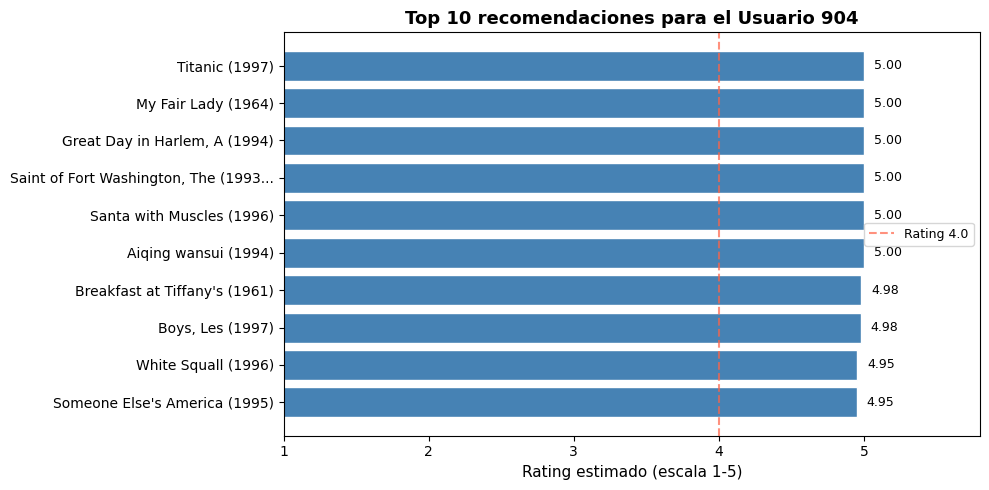

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
titles_short = [t[:35] + '...' if len(t) > 35 else t for t in top_recs['title']]
vals = top_recs['rating_estimado'].values

bars = ax.barh(titles_short[::-1], vals[::-1], color='steelblue', edgecolor='white')
ax.set_xlim(1, 5.8)
ax.set_xlabel('Rating estimado (escala 1-5)', fontsize=11)
ax.set_title(f'Top {top_n} recomendaciones para el Usuario {user_id}',
             fontweight='bold', fontsize=13)
for bar, val in zip(bars, vals[::-1]):
    ax.text(bar.get_width() + 0.07, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
ax.axvline(4.0, color='tomato', linestyle='--', alpha=0.7, label='Rating 4.0')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

  ---
## Conclusiones

<div style="background:#f8f9fa; padding:15px 20px; border-left:4px solid #1F3A5F; margin:20px 0; font-family:Georgia, serif; line-height:1.8;">

**¿Qué aprendimos?**

1. **El problema es escasez, no privacidad.** Solo el 6.3% de la matriz tiene información real. Sin embargo, ese fragmento es suficiente para encontrar patrones y hacer predicciones útiles. Los sistemas de recomendación no funcionan porque alguien te observe — funcionan porque la escasez tiene estructura.

2. **La factorización $R \approx UV^T$ captura lo invisible.** Los vectores $u_i$ y $v_j$ no representan características explícitas como "le gustan las comedias" — emergen solos del patrón de calificaciones y codifican preferencias que quizás el propio usuario no sabría articular.

3. **El centrado por usuario no es un detalle menor.** Sin él, el algoritmo mezcla el sesgo de escala personal con las preferencias reales, y la calidad de las recomendaciones cae notablemente.

4. **SoftImpute es elegante porque es simple.** SVD + umbral suave + actualización iterativa. Sin capas ocultas, sin hiperparámetros complicados. La regularización nuclear hace el trabajo de controlar la complejidad automáticamente.

5. **RMSE ~1 es un punto de partida razonable.** No es perfecto, pero en la práctica basta para separar lo que un usuario claramente disfrutaría de lo que probablemente no le interesaría. Extensiones como ALS, SVD++ o Neural Collaborative Filtering pueden reducir este error significativamente.

</div>

<div style="text-align:center; color:#1F3A5F; font-style:italic; margin-top:20px; font-family:Georgia, serif; font-size:1.1em;">
No hay alguien espiando tus gustos; hay matemáticas encontrando patrones donde nosotros solo vemos recomendaciones. Hoy usamos estos modelos para predecir qué película podría gustarnos; mañana quizá los usemos para predecir qué mundos podrían albergar vida.
</div>